## import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

I0000 00:00:1773698843.137758   37021 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773698843.138100   37021 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773698843.166145   37021 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.0.1)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(
I0000 00:00:1773698843.953589   37021 port.cc:153] on

## load the dataset

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

## convert target to categorical

In [3]:
y = to_categorical(y)

## train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## feature scaling

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## function to build networks

In [6]:
def build_model(layers):
    
    model = Sequential()
    
    model.add(Dense(layers[0], activation='relu', input_shape=(13,)))
    
    for units in layers[1:]:
        model.add(Dense(units, activation='relu'))
        
    model.add(Dense(3, activation='softmax'))
    
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

## define architectures

In [7]:
architectures = {
    "Shallow":[64],
    "Medium":[128,64],
    "Deep":[256,128,64],
    "Very Deep":[512,256,128,64]
}

## train 

In [8]:
results = {}

for name, arch in architectures.items():
    
    print("Training:", name)
    
    model = build_model(arch)
    
    start = time.time()
    
    history = model.fit(
        X_train,
        y_train,
        epochs=100,
        validation_split=0.2,
        verbose=0
    )
    
    end = time.time()
    
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    
    results[name] = {
        "history": history,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "time": end-start
    }

Training: Shallow


/home/t4tum/anaconda3/envs/python-starter/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773700044.700656   37021 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Training: Medium
Training: Deep
Training: Very Deep


## results

In [9]:
for name in results:
    print("\n",name)
    print("Training Accuracy:", results[name]["train_acc"])
    print("Validation Accuracy:", results[name]["val_acc"])
    print("Training Time:", results[name]["time"])


 Shallow
Training Accuracy: 1.0
Validation Accuracy: 0.9655172228813171
Training Time: 5.667501449584961

 Medium
Training Accuracy: 1.0
Validation Accuracy: 1.0
Training Time: 5.536960124969482

 Deep
Training Accuracy: 1.0
Validation Accuracy: 1.0
Training Time: 5.940541744232178

 Very Deep
Training Accuracy: 1.0
Validation Accuracy: 1.0
Training Time: 6.2629358768463135


## plot learning curves

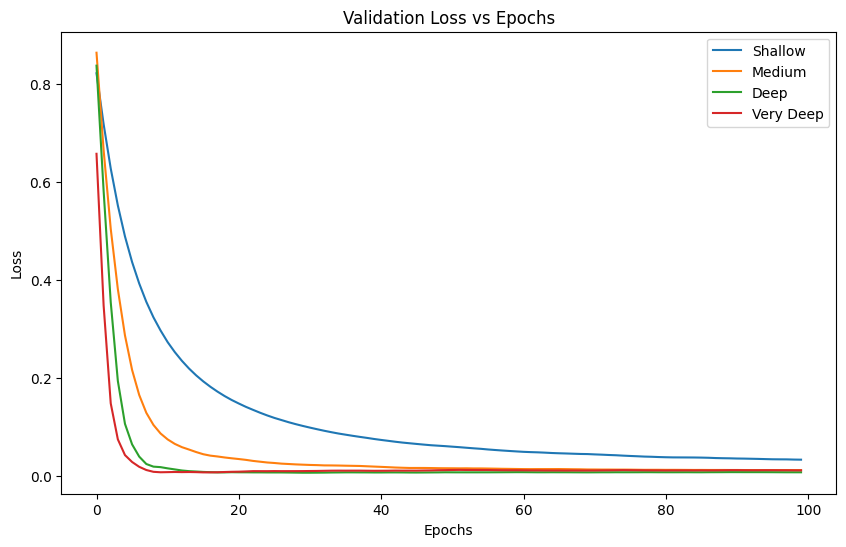

In [10]:
plt.figure(figsize=(10,6))

for name in results:
    plt.plot(
        results[name]["history"].history['val_loss'],
        label=name
    )

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

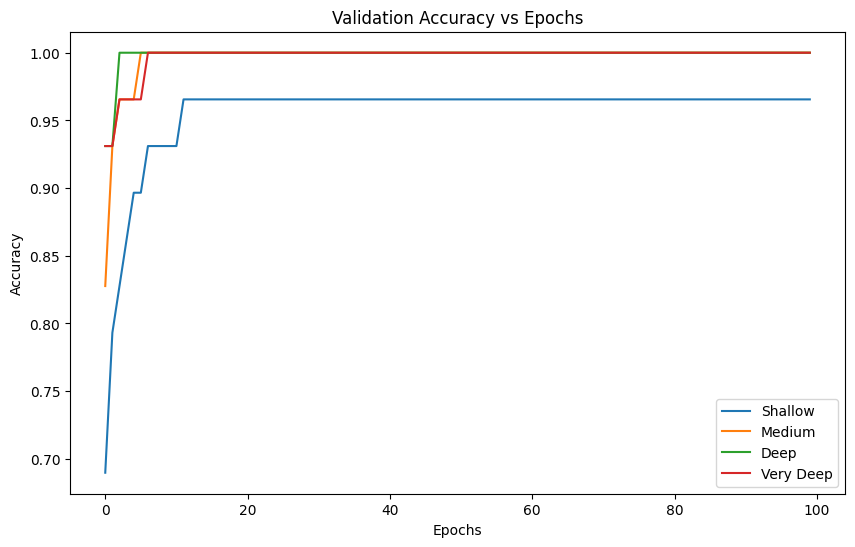

In [11]:
plt.figure(figsize=(10,6))

for name in results:
    plt.plot(
        results[name]["history"].history['val_accuracy'],
        label=name
    )

plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## At what depth does overfitting begin to appear?

Overfitting appears typically in the Very Deep network [512, 256, 128, 64]

## How to mitigate overfitting in deep networks?

Several techniques :

### Dropout

Randomly disables neurons.

example:

from tensorflow.keras.layers import Dropout

model.add(Dropout(0.3))

### Early Stopping

Stop training when validation loss increases.

from tensorflow.keras.callbacks import EarlyStopping

early = EarlyStopping(patience=10)

### L2 Regularization

Penalizes large weights.

Dense(128, activation='relu',

kernel_regularizer='l2')

### Reduce model size

example : 

instead of using [512, 256, 128, 64] , 

we use [128, 64]

### More data

More data improves generalization.